In [1]:
# Importing the libraries I need

import pandas as pd
import numpy as np
from scipy import stats

In [2]:
# loading the final sampled dataset

df = pd.read_csv("WC2026_Defenders_Final_Sample.csv")

# I am checking the first few rows
print(df.head())

   Rank             Player Position         Squad  Age  Born  90s  Tackles  \
0   928      Arthur Theate       DF       Belgium   26  2000  2.5        0   
1   966    Virgil van Dijk       DF   Netherlands   34  1991  4.3        1   
2   630       César Montes       DF        Mexico   29  1997  3.5        1   
3   427     Yasser Ibrahim       DF         Egypt   33  1993  5.2        6   
4   591  Mbekezeli Mbokazi       DF  South Africa   20  2005  4.0        5   

   Interceptions (Int) Tournament Stage  Interceptions per 90 mins  \
0                    3         Knockout                   1.200000   
1                    3         Knockout                   0.697674   
2                    2         Knockout                   0.571429   
3                    3         Knockout                   0.576923   
4                    4         Knockout                   1.000000   

  Eligible Defender FBref Player ID  
0               Yes        df8d6029  
1               Yes        e06683c

In [3]:
# I am separating the two tournament groups again

knockout = df[df["Tournament Stage"] == "Knockout"]

group_stage = df[
    df["Tournament Stage"] == "Group Stage Eliminated"
]

In [4]:
# I am creating a function to calculate the 95% confidence interval
# for the mean interceptions per 90 minutes

def confidence_interval(data):
    n = len(data)
    mean = data.mean()
    std = data.std(ddof=1)

    standard_error = std / np.sqrt(n)

    margin_error = stats.t.ppf(0.975, df=n-1) * standard_error

    lower = mean - margin_error
    upper = mean + margin_error

    return mean, lower, upper

In [5]:
# Now I am calculating the 95% confidence interval
# for knockout-stage defenders

ko_mean, ko_lower, ko_upper = confidence_interval(
    knockout["Interceptions per 90 mins"]
)

print("Knockout mean:", ko_mean)
print("95% CI:", ko_lower, "to", ko_upper)

Knockout mean: 0.9281111091750001
95% CI: 0.7578341100926866 to 1.0983881082573135


In [6]:
# Now I am calculating the same confidence interval
# for group-stage eliminated defenders

gs_mean, gs_lower, gs_upper = confidence_interval(
    group_stage["Interceptions per 90 mins"]
)

print("Group-stage mean:", gs_mean)
print("95% CI:", gs_lower, "to", gs_upper)

Group-stage mean: 1.215229362925
95% CI: 0.9904735326087626 to 1.4399851932412373


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# I am calculating the 95% confidence interval margin
# for each tournament group

def ci_margin(data):
    n = len(data)
    std = data.std(ddof=1)
    standard_error = std / np.sqrt(n)

    margin = stats.t.ppf(
        0.975,
        df=n - 1
    ) * standard_error

    return margin

In [9]:
# I am calculating the mean and confidence interval margin
# for both groups

means = [
    knockout["Interceptions per 90 mins"].mean(),
    group_stage["Interceptions per 90 mins"].mean()
]

ci_margins = [
    ci_margin(knockout["Interceptions per 90 mins"]),
    ci_margin(group_stage["Interceptions per 90 mins"])
]

groups = [
    "Knockout",
    "Group Stage Eliminated"
]

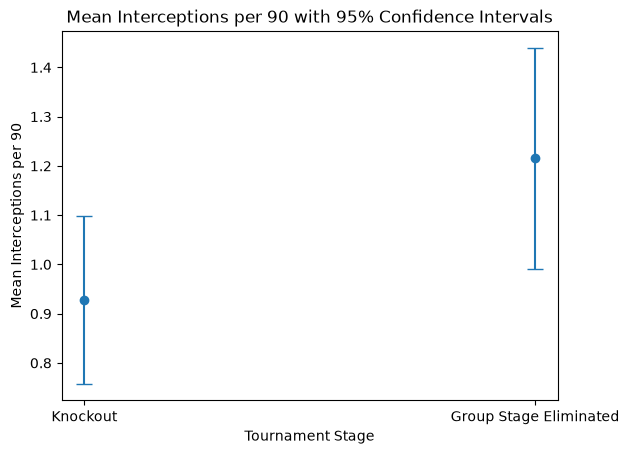

In [10]:
# I am creating an error-bar plot to compare the mean
# interceptions per 90 with 95% confidence intervals

plt.errorbar(
    groups,
    means,
    yerr=ci_margins,
    fmt="o",
    capsize=6
)

plt.title("Mean Interceptions per 90 with 95% Confidence Intervals")
plt.xlabel("Tournament Stage")
plt.ylabel("Mean Interceptions per 90")
plt.show()

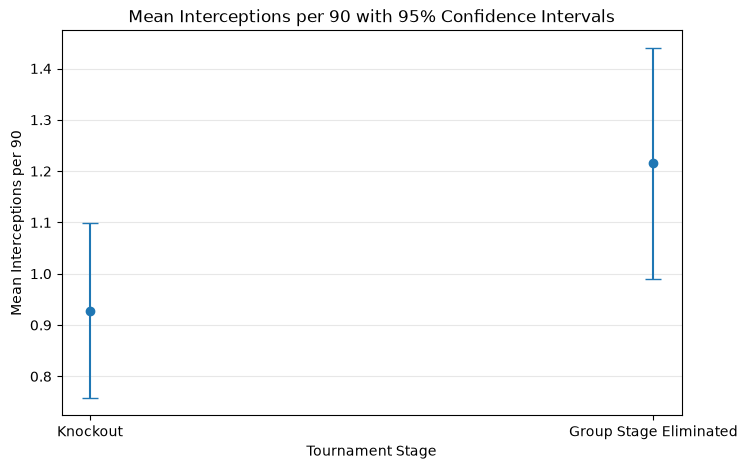

In [11]:
# I am creating an error-bar plot to compare the mean
# interceptions per 90 with 95% confidence intervals

plt.figure(figsize=(8, 5))

plt.errorbar(
    groups,
    means,
    yerr=ci_margins,
    fmt="o",
    capsize=6
)

plt.title("Mean Interceptions per 90 with 95% Confidence Intervals")
plt.xlabel("Tournament Stage")
plt.ylabel("Mean Interceptions per 90")
plt.grid(axis="y", alpha=0.3)

plt.show()